# Example 1: an open two-level system, three detection schemes

A two-level emitter with radiative decay and pure dephasing is the reference calculation of QuDPy-FDGF: everything is known analytically, so every step can be checked. In this notebook you will:

- build the model with QuTiP and pass it to the solver, with collapse-channel rates stored separately from their operators;
- check that the ground state is stationary under the dissipative dynamics;
- compute the third-order rephasing response from two pathways (written by hand, then generated with UFSS);
- detect the same pathways three ways: polarization, action population and integrated fluorescence;
- verify the result against an exact analytical identity.

Natural units: $\hbar=1$, energies and rates in eV, times in eV$^{-1}$.

## 0. Imports

`qutip` builds the physical operators. `qudpy_fdgf` provides the model, the solver, the pathways and the observables. UFSS (Section 4) and the plotter (Section 5) are imported where they are used.

The cells from here to Section 7 whose first line is a numbered comment (`# 1. Model`, ..., `# 6. Results`) form, together with this one, a complete script of about 70 lines: it is the listing of the article, which extracts it from this notebook.

In [1]:
import numpy as np
import qutip as qt

from qudpy_fdgf import (
    EigenbasisKModel,
    FrequencyPathway,
    ObservableSpec,
    SpectroscopySolver,
    standard_nq_protocol,
)

## 1. Physical model

The basis is ordered $\{|g\rangle,|e\rangle\}$. The Hamiltonian and the transition operator are

$$
H=\omega_{eg}\,|e\rangle\langle e|,
\qquad
\mu=d\left(|e\rangle\langle g|+|g\rangle\langle e|\right).
$$

The dynamics follow the Lindblad (GKSL) generator

$$
\mathcal L[\rho]=-i[H,\rho]+\sum_c\gamma_c\Big(L_c\rho L_c^\dagger-\tfrac12\{L_c^\dagger L_c,\rho\}\Big).
$$

Two channels act on the system:

- radiative relaxation, $L_1=|g\rangle\langle e|$ with rate $\gamma_1$;
- pure dephasing, $L_\phi=\sigma_z$. Because $\mathcal D[\sigma_z]\rho_{eg}=-2\rho_{eg}$, a channel rate $\gamma_\phi/2$ makes the optical coherence decay at the pure-dephasing rate $\gamma_\phi$. Together, the coherence decays at $\gamma_2=\gamma_1/2+\gamma_\phi$.

The rate $\gamma_c$ is a separate number: it is never folded into $L_c$.

In [2]:
# 1. Model: QuTiP operators in the {|g>, |e>} basis (hbar = 1, energies in eV)
omega_eg = 2.0        # transition energy (eV)
dipole = 0.5          # transition dipole d
gamma_1 = 0.04        # radiative relaxation rate (eV)
gamma_phi = 0.03      # pure-dephasing rate (eV)

ground = qt.basis(2, 0)
excited = qt.basis(2, 1)

H = omega_eg * excited * excited.dag()
mu = dipole * (excited * ground.dag() + ground * excited.dag())

P_ground = ground * ground.dag()      # also the initial density matrix
P_excited = excited * excited.dag()
L_radiative = ground * excited.dag()  # |g><e|
L_dephasing = qt.sigmaz()

## 2. Model and solver

`EigenbasisKModel` takes the Hamiltonian, the transition operator and the collapse channels as `(operator, rate)` pairs. The dictionary `observable_op_arrays` names the operators that the detection schemes of Section 5 will read. The adapter converts each `Qobj` to a NumPy array.

The solver evaluates the response with resolvents $[(\eta-i\omega)\mathbb 1-\mathcal L]^{-1}$. The small regularization $\eta$ adds a numerical width $\eta$ to every pole. The `dense` backend stores the full Liouville matrix, which is the right choice for two levels.

In [3]:
# 2. Solver: model with (operator, rate) channels, backend, broadening eta
model = EigenbasisKModel(
    H,
    mu,
    c_ops_raw=(
        (L_radiative, gamma_1),
        (L_dephasing, gamma_phi / 2),
    ),
    observable_op_arrays={
        "polarization": mu,
        "excited_population": P_excited,
    },
)

eta = 0.002          # resolvent broadening (eV)
solver = SpectroscopySolver(backend="dense", eta=eta)
solver.feed_model(model)          # default initial state: the ground state

Channels are named by their input order: `c_op_0` is the radiative relaxation and `c_op_1` the dephasing.

In [4]:
print("Jump channels:", solver.jump_channel_names())

Jump channels: ('c_op_0', 'c_op_1')


## 3. Initial state

The calculation starts from $\rho_0=|g\rangle\langle g|$, the solver default. At zero temperature this state must be stationary under $\mathcal L$. QuTiP can confirm it: `qt.liouvillian` builds the same generator, and a stationary state satisfies $\mathcal L[\rho_0]=0$.

In [5]:
c_ops = [np.sqrt(gamma_1) * L_radiative, np.sqrt(gamma_phi / 2) * L_dephasing]  # QuTiP wants sqrt(rate) * L
liouvillian = qt.liouvillian(H, c_ops)
drho = qt.vector_to_operator(liouvillian * qt.operator_to_vector(P_ground))

print(f"max |L[rho_0]| = {np.abs(drho.full()).max():.1e}")
assert np.abs(drho.full()).max() < 1e-14

max |L[rho_0]| = 0.0e+00


## 4. Third-order rephasing pathways

For a two-level system, the rephasing $\chi^{(3)}$ signal has two pathways, each named by its ordered light–matter interactions ($B$ acts on the bra side, $K$ on the ket side, $u$ raises and $d$ lowers):

$$R_1=(B_u,K_u,B_d)\ \text{(stimulated emission)},\qquad R_2=(B_u,B_d,K_u)\ \text{(ground-state bleach)}.$$

Both follow the coherence orders $q=(-1,0,+1)$. There is no excited-state absorption, because the model has no doubly excited level.

**Written by hand.** A `FrequencyPathway` is just the list of interactions.

In [6]:
# 3. Pathways: ordered interaction labels
pathway_r1 = FrequencyPathway(
    name="R1", interactions=("Bu", "Ku", "Bd"), component="rephasing", detection="polarization"
)
pathway_r2 = FrequencyPathway(
    name="R2", interactions=("Bu", "Bd", "Ku"), component="rephasing", detection="polarization"
)
pathways = (pathway_r1, pathway_r2)

**Generated with UFSS.** For larger systems you do not want to enumerate pathways yourself. UFSS builds the diagrams from a phase-discrimination pattern (one `(bra, ket)` count per pulse), and `translate_ufss_diagrams` converts them to `FrequencyPathway` objects. `maximum_manifold = 1` stops the ladder at one excitation.

In [7]:
import ufss
from qudpy_fdgf import translate_ufss_diagrams

diagram_generator = ufss.DiagramGenerator()
diagram_generator.set_phase_discrimination([(0, 1), (1, 0), (1, 0)])   # rephasing
diagram_generator.maximum_manifold = 1
diagram_generator.efield_times = [np.array([0.0, 0.0])] * 3
ufss_diagrams = diagram_generator.get_diagrams(np.arange(3, dtype=float))

ufss_pathways = translate_ufss_diagrams(
    ufss_diagrams, component="rephasing", names=["R1", "R2"], detection="polarization"
)
for pathway in ufss_pathways:
    labels = tuple(interaction.label for interaction in pathway.interactions)
    print(f"{pathway.name}: {labels}, q = {pathway.coherence_orders}")

# The generated pathways are the ones written by hand above.
assert [tuple(i.label for i in p.interactions) for p in ufss_pathways] == [("Bu", "Ku", "Bd"), ("Bu", "Bd", "Ku")]

R1: ('Bu', 'Ku', 'Bd'), q = (-1, 0, 1)
R2: ('Bu', 'Bd', 'Ku'), q = (-1, 0, 1)


## 5. Protocol and spectrum

`standard_nq_protocol` says how the three interactions and the intervals between them are treated:

- `nq_interval=1`: the first interval is the one-quantum coherence, Fourier-transformed to the axis `omega_1q`;
- `detection_interval=3`: the third interval is the emitted coherence, transformed to `omega_emit`;
- the remaining interval $t_2$ (the population waiting time) stays in the time domain and is fixed with `fixed_coordinates`.

`generate_spectrum` returns a `SpectrumResult`. The rephasing signal is `components["rephasing"]`. The rephasing peak sits at $\omega_{1Q}\approx-\omega_{eg}$ (negative excitation axis) and $\omega_{\rm emit}\approx+\omega_{eg}$.

In [8]:
# 4. Protocol: t1 and t3 in frequency, the waiting time t2 in time
protocol = standard_nq_protocol(
    order=1,
    nq_interval=1,
    detection_interval=3,
    n_interactions=3,
    nq_axis="omega_1q",
    detection_axis="omega_emit",
)
t2 = 10.0                         # population waiting time (eV^-1)

We first evaluate the rephasing component on a fine $101\times101$ grid, to look at the peak.

In [9]:
omega_1q = np.linspace(-2.5, -1.5, 101)
omega_emit = np.linspace(1.5, 2.5, 101)

rephasing_result = solver.generate_spectrum(
    protocol,
    axes={"omega_1q": omega_1q, "omega_emit": omega_emit},
    fixed_coordinates={"t2": t2},
    pathways=pathways,
)
rephasing = rephasing_result.components["rephasing"]
print("array shape (omega_1q, omega_emit):", rephasing.shape)

array shape (omega_1q, omega_emit): (101, 101)


### Plot

`SpectroscopyPlotter` only displays a `SpectrumResult`; it does not recompute anything. `view="all"` shows the real, imaginary and absolute parts side by side. `detection_phase` rotates the complex signal before display, $S_{\rm display}=e^{i\phi}S$; with `0.0` you see the solver's raw convention, and the absolute panel does not depend on it. A phase of $\pi/2$ is the usual choice to display an absorptive real part.

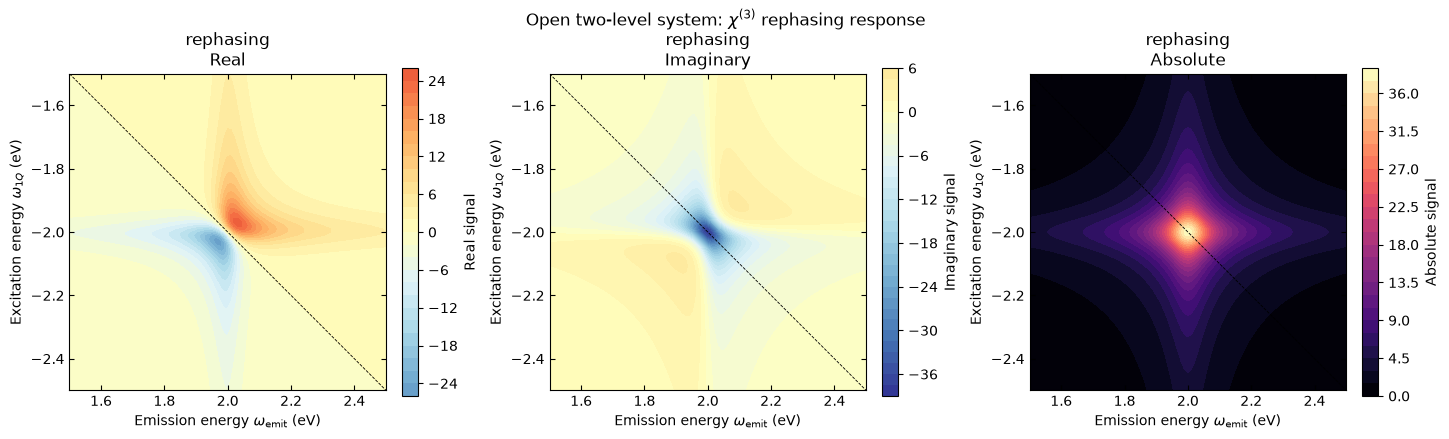

In [10]:
from qudpy_fdgf import SpectroscopyPlotter

plotter = SpectroscopyPlotter(detection_phase=0.0)
rephasing_figure = plotter.plot_spectrum_result(
    rephasing_result,
    params={
        "source": "components",
        "names": ["rephasing"],
        "view": "all",
        "normalization": "row",
        "title": r"Open two-level system: $\chi^{(3)}$ rephasing response",
        "labels": (
            r"Emission energy $\omega_{\mathrm{emit}}$ (eV)",
            r"Excitation energy $\omega_{1Q}$ (eV)",
        ),
        "diagonals": "auto",
        "style": {"cmap": "RdYlBu_r", "abs_cmap": "magma", "levels": 30, "contour_lines": False},
        "show": True,
    },
)

## 6. Three detection schemes from one propagation

The solver propagates the three field interactions once. Several observables then read the same propagated state:

- `"polarization"`: the optical coherence, contracted with the transition operator;
- `ObservableSpec.action`: a fourth interaction `Bu` projects the final coherence ($q=+1$) onto a population ($q=0$), and the excited-state population is measured;
- `ObservableSpec.mean_jump`: the same projection, then the radiative jumps are counted over a time window $T$.

The fourth interaction belongs to the observable, not to the pathway, which stays third order. We choose $T=5/\gamma_1$ so that most radiative decay is captured.

In [11]:
# 5. Observables: one propagation, three detection schemes
radiative_channel = solver.jump_channel_names()[0]    # "c_op_0"
window = 5.0 / gamma_1

observables = {
    "polarization": "polarization",
    "action_population": ObservableSpec.action(
        "action_population", fourth_interaction="Bu", operator="excited_population"
    ),
    "action_fluorescence": ObservableSpec.mean_jump(
        "action_fluorescence", radiative_channel, time_window=(0.0, window), fourth_interaction="Bu"
    ),
}

omega_1q = np.linspace(-2.5, -1.5, 41)
omega_emit = np.linspace(1.5, 2.5, 41)
result = solver.generate_spectrum(
    protocol,
    axes={"omega_1q": omega_1q, "omega_emit": omega_emit},
    fixed_coordinates={"t2": t2},
    pathways=pathways,
    observables=observables,
)

The three observables, for both pathways:

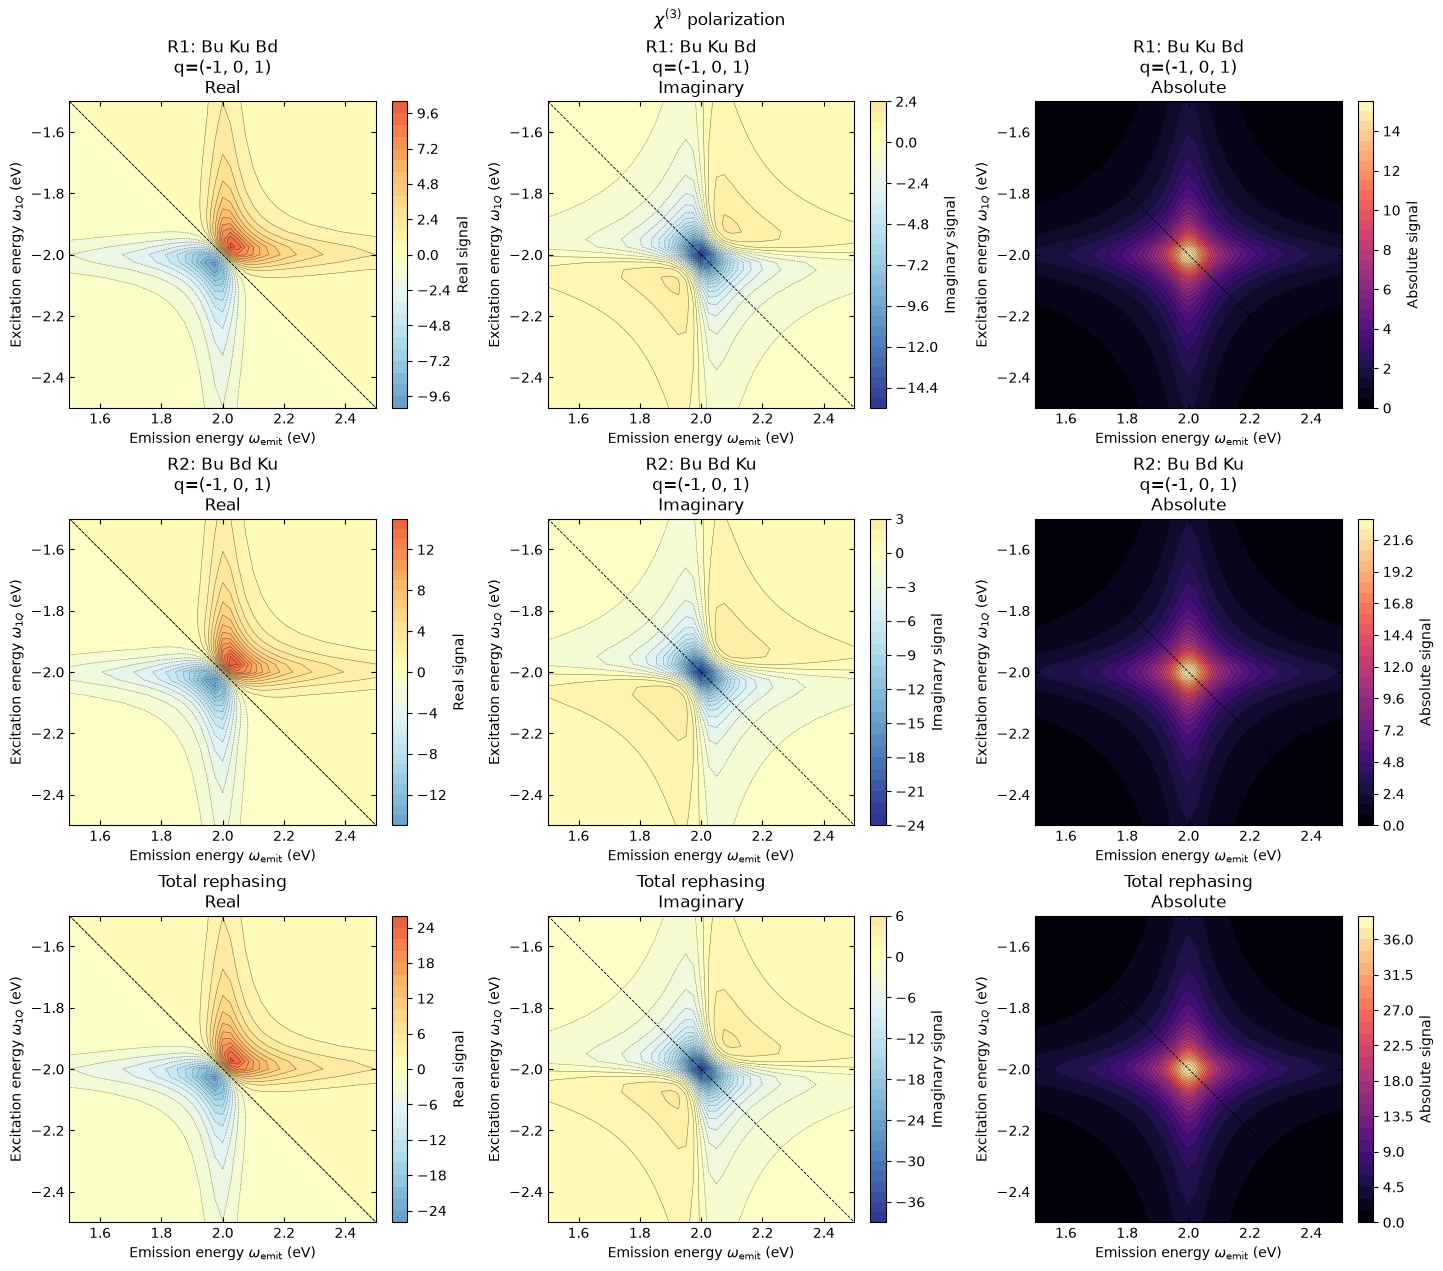

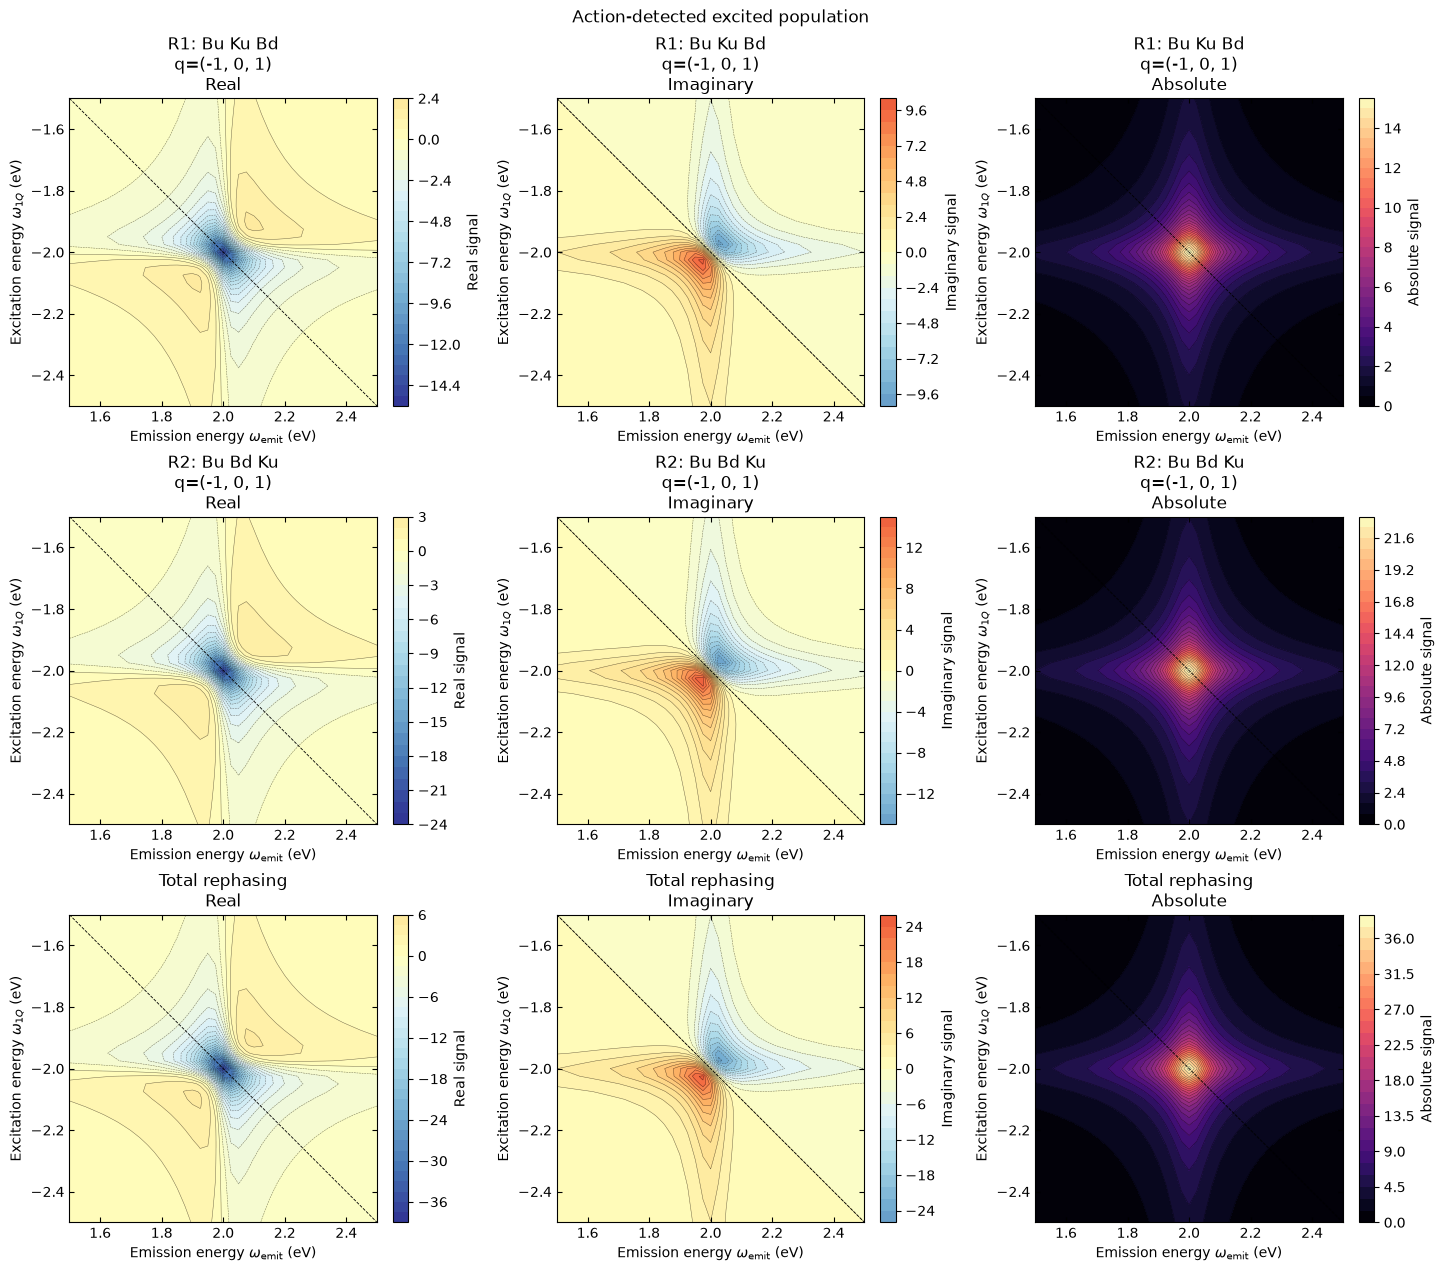

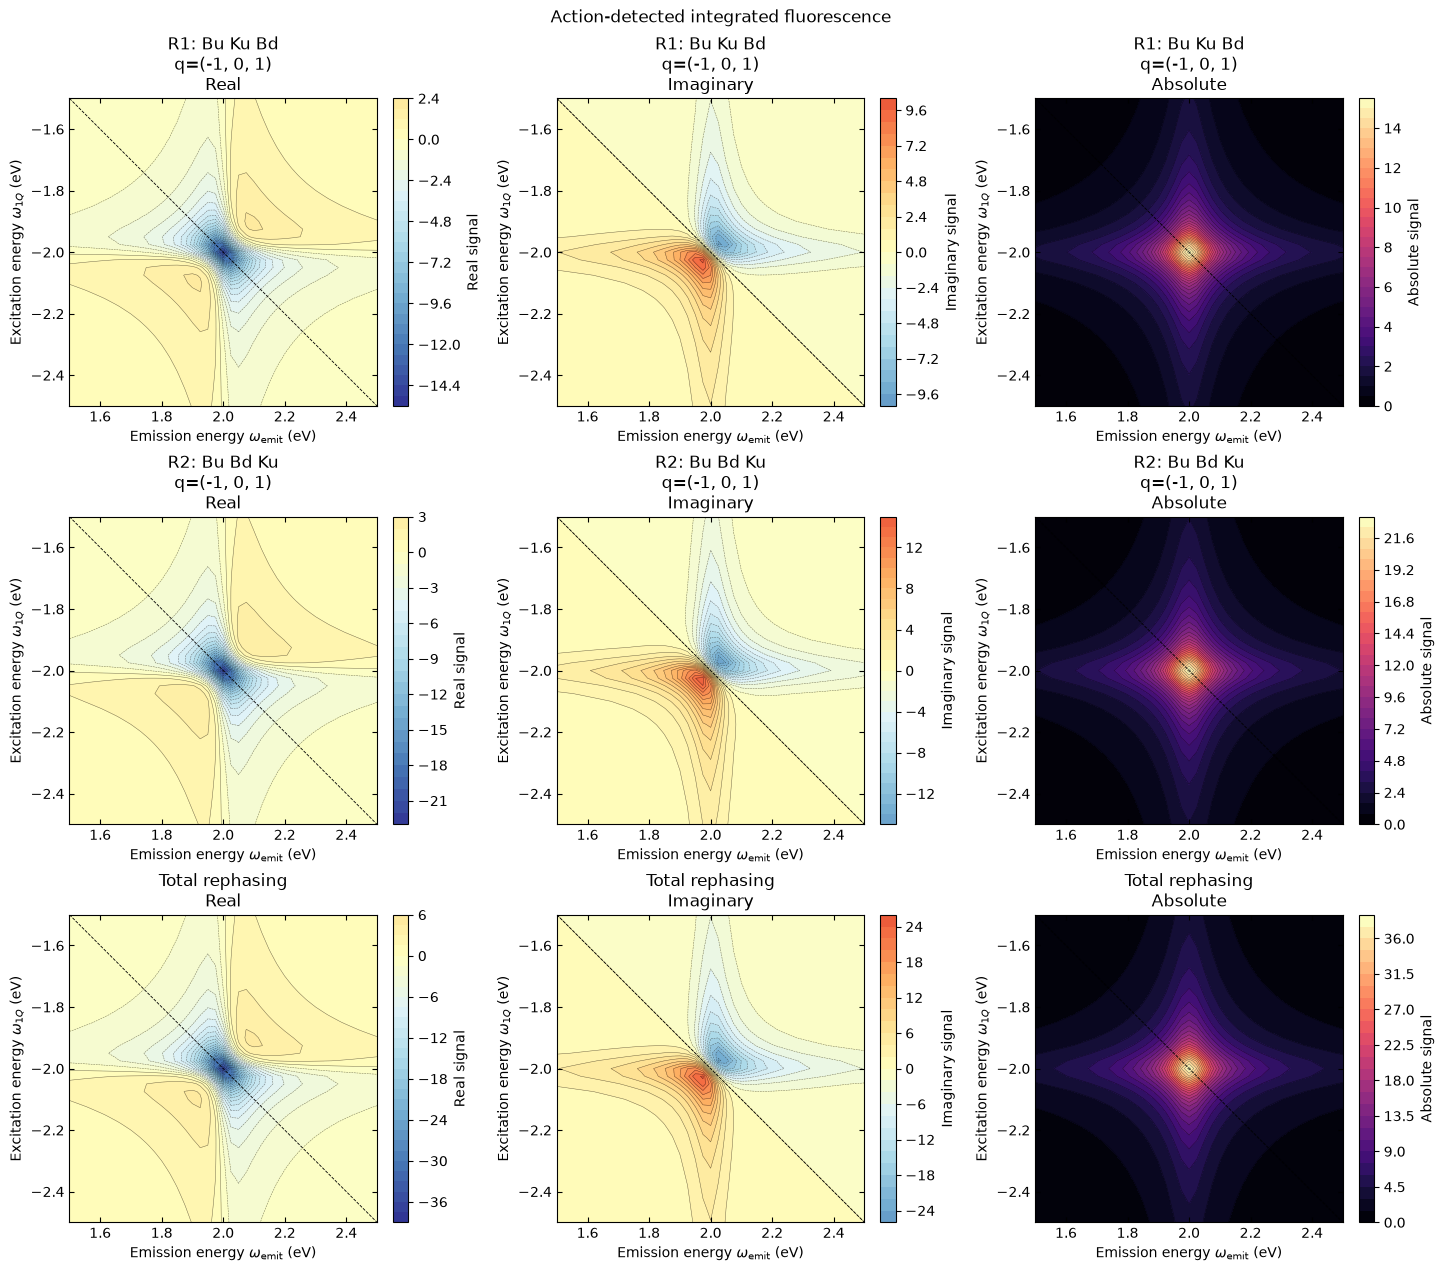

In [12]:
observable_figures = {}
for name, title in (
    ("polarization", r"$\chi^{(3)}$ polarization"),
    ("action_population", "Action-detected excited population"),
    ("action_fluorescence", "Action-detected integrated fluorescence"),
):
    observable_figures[name] = plotter.plot_spectrum_result(
        result,
        params={
            "source": "observables",
            "observable": name,
            "pathways": ["R1", "R2"],
            "view": "all",
            "normalization": "row",
            "title": title,
            "labels": (
                r"Emission energy $\omega_{\mathrm{emit}}$ (eV)",
                r"Excitation energy $\omega_{1Q}$ (eV)",
            ),
            "diagonals": "auto",
            "show": True,
        },
    )

## 7. Verification against analytical identities

Two exact relations hold for this model, and neither depends on how the spectrum looks.

1. The projection turns the coherence into a population with a factor $-i$: $S_{\rm pop}^{(4)}=-i\,S_{\rm pol}^{(3)}$.
2. For pathway $R_1$, radiative jumps are counted at rate $\gamma_1P_e$, so the fluorescence over the window equals $1-e^{-\gamma_1T}$ times the population signal. Here $\gamma_1T=5$.

The cell reports the peak position and both checks.

In [13]:
# 6. Results: complex arrays indexed [omega_1q, omega_emit]
S_pol = result.observables["polarization"]["R1"]
S_pop = result.observables["action_population"]["R1"]
N_fl = result.observables["action_fluorescence"]["R1"]

i, j = np.unravel_index(np.argmax(np.abs(S_pol)), S_pol.shape)
print(f"peak = ({omega_1q[i]:.3f}, {omega_emit[j]:.3f}) eV")

identity_error = np.max(np.abs(S_pop + 1j * S_pol)) / np.max(np.abs(S_pol))
print(f"max|S_pop + i S_pol| / max|S_pol| = {identity_error:.1e}")

fluorescence_ratio = (N_fl[i, j] / S_pop[i, j]).real
print(f"N_fl / S_pop = {fluorescence_ratio:.6f}; 1 - exp(-5) = {1 - np.exp(-5):.6f}")

assert identity_error < 1e-12
assert abs(fluorescence_ratio - (1 - np.exp(-gamma_1 * window))) < 1e-3

peak = (-2.000, 2.000) eV
max|S_pop + i S_pol| / max|S_pol| = 0.0e+00
N_fl / S_pop = 0.993262; 1 - exp(-5) = 0.993262


## 8. Save the results

The analysis notebook `validation/analysis/example1_analysis.ipynb` starts from these files, so it compares against exactly the calculation shown here. The arrays go into one `.npz` file and the figures into PDF files.

In [14]:
from pathlib import Path

results = Path("../validation/results")
(results / "data").mkdir(parents=True, exist_ok=True)
(results / "figure").mkdir(parents=True, exist_ok=True)

np.savez(
    results / "data" / "example1.npz",
    omega_eg=omega_eg, dipole=dipole, gamma_1=gamma_1, gamma_phi=gamma_phi,
    eta=eta, t2=t2, window=window,
    omega_1q_fine=np.linspace(-2.5, -1.5, 101), omega_emit_fine=np.linspace(1.5, 2.5, 101),
    rephasing_fine=rephasing,
    omega_1q=omega_1q, omega_emit=omega_emit,
    **{f"{name}_{path}": result.observables[name][path]
       for name in ("polarization", "action_population", "action_fluorescence")
       for path in ("R1", "R2")},
)
rephasing_figure.figure.savefig(results / "figure" / "example1_rephasing.pdf", bbox_inches="tight")
for name, plot in observable_figures.items():
    plot.figure.savefig(results / "figure" / f"example1_{name}.pdf", bbox_inches="tight")
print("saved", results / "data" / "example1.npz")

saved ..\validation\results\data\example1.npz


## Summary

- The model is built with QuTiP; collapse operators and rates are passed separately.
- The ground state is stationary: $\mathcal L[\rho_0]=0$.
- Radiative relaxation and pure dephasing broaden the third-order rephasing peak at $(\omega_{1Q},\omega_{\rm emit})=(-\omega_{eg},+\omega_{eg})$.
- One propagation of the two pathways gives polarization, action population and integrated fluorescence; the fourth projection pulse belongs to the observable.
- The results match exact identities (machine precision for the population identity; the fluorescence ratio equals $1-e^{-5}$ to six digits).